# CBE 162-Fall 2026 Lab 2

## Ordinary Differential equations


Here we will focus on using Python to numerically solve ODEs. There are many libraries for this purpose, but this tutorial will focus on the scipy module.

- See [https://docs.scipy.org/](https://docs.scipy.org/) for the full documentation on scipy and numpy.
- See [https://docs.scipy.org/doc/scipy/reference/integrate.html](https://docs.scipy.org/doc/scipy/reference/integrate.html) for info just relating to the integrate package in scipy.


Begin with importing numpy, matplotlib.pyplot, and the integrate package from scipy

In [3]:
%pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

## First order ODEs

Let's begin with a nonlinear, first-order differential equation:

$\tau \dfrac{dy}{dt} = u - k\sqrt{y}$

Let's first define some of our inputs, then define a function for the model.

In [5]:
tau = 1.0
u = 1.5
k = 0.75
y_0 = 11

In [6]:
def modelfunction(t,y):
    return (u-k*(y**0.5))/tau


See [https://matplotlib.org/stable/tutorials/index.html](https://matplotlib.org/stable/tutorials/index.html) for the documentation for matplot lib in order to create neater charts.

The solution.y variable has shape (n_variables, n_t), so when you unpack it, it automatically makes arrays of 1 less dimension for each "row". Here, that would be (n_t,).

The documentation for integrate.solve_ivp includes other optional arguments as well. You can specify a method of integration, such as method = RK45 for a an explicit 4th or Runge-Kutta method, method = DOP853 for an explicit 8th order Runge-Kutta method. There are several implicit methods as well.  

The integrate package has other modules that may be useful as well.
Note that solve_ivp requires the input function to have independent variable as the first argument.
The module is also smart enough to know how many time steps to put in, although you can define time steps if you wanted to.

Next let's use some tools in numpy and scipy.integrate. Define an input vector for the independant variable, t. Then use tools available in scipy.integrate, such as the solve_ivp package.

<class 'scipy.integrate._ivp.ivp.OdeResult'>


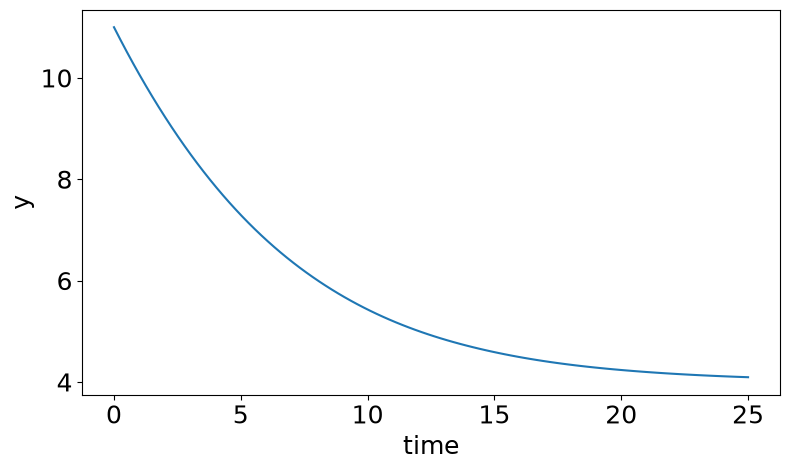

In [9]:

t_initial = 0
t_final = 25
t = np.linspace(t_initial, t_final, 100)

solution = integrate.solve_ivp(modelfunction, [t_initial, t_final], [y_0], t_eval = t) #t_eval is an optional argument

print(type(solution)) #What type of object does solve_ivp use?

t_axis = solution.t     #the .t is an argument to spit out the time input array
y = solution.y[0]       #the .y is an argument on the robject that solve_ivp spits out. The [0] is needed or it's the wrong dimension for .plot

plt.figure(figsize=(9,5))
plt.rc("font", size = 18)
plt.plot(t_axis, y)
plt.xlabel('time')
plt.ylabel('y')
plt.show()


## Systems of ODEs

Consider the following system of equations:

$(1)  \quad \dfrac{d y_1}{d t} = y_1 \cos{t} +y_2 \sin{t}$

$(2)  \quad \dfrac{d y_2}{d t} = my_1 +b$


Begin by defining inputs and the model function:

In [10]:
m = 3.5
b = -1.1
y1_0 = 4
y2_0 = 1

def model(t, y): #independant variable first, then dependant. Here y will be a vector.
    y_1, y_2 = y
    DE1 = y_1*np.cos(t)-y_2*np.sin(t)
    DE2 = m*y_1+b
    return DE1, DE2

Our function has 2 outputs now, and solve_ivp is capable of handling them so long as each ODE is explicit. We will plot $y_1$ and $y_2$ against time and $y_2$ against $y_1$

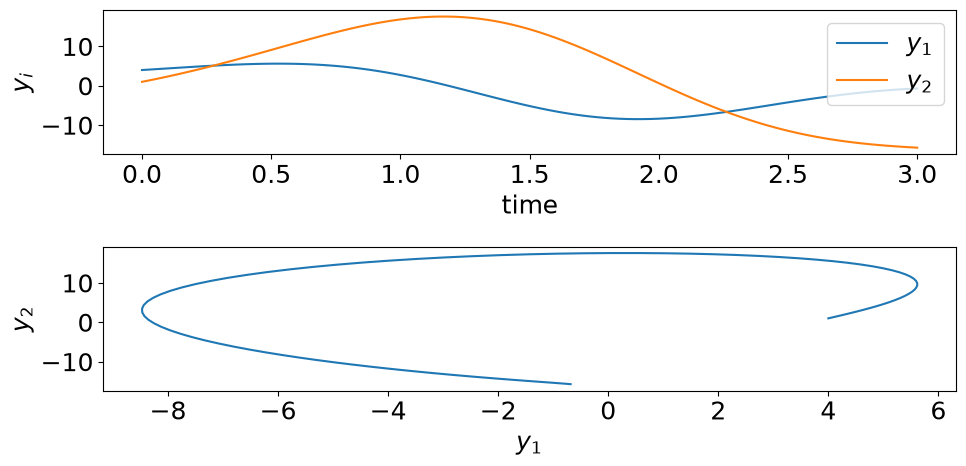

In [11]:
t_initial = 0
t_final = 3

t = np.linspace(t_initial, t_final, 100) #Recall with solve_ivp defining the domain's resolution is optional

sol = integrate.solve_ivp(model, (t_initial, t_final), (y1_0, y2_0), t_eval = t)

t = sol.t
y1, y2 = sol.y #have 2 outputs now, and the array is the right size.

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
#
plt.plot(t,y1, label = '$y_1$')
plt.plot(t,y2, label = '$y_2$')
plt.legend(loc = "best")
plt.xlabel("time")
plt.ylabel('$y_i$')
#
plt.subplot(2,1,2)
plt.plot(y1,y2)
plt.xlabel("$y_1$")
plt.ylabel("$y_2$")
plt.tight_layout()
plt.show()

# Stiff ODEs

### Introduction to Stiff Systems

In this section, we will explore a "stiff" system of ordinary differential equations. Stiff systems are common in chemical engineering, particularly when we have reactions with a wide range of timescales including both fast and slow reactions. For these systems, standard explicit solvers require impractically small time steps to maintain numerical stability, even when the solution itself is changing slowly.

The system of ODEs we will use is a classic stiff ODE example from chemical kinetics, known as Robertson's problem. It involves three species with very different reaction rates, creating a wide range of timescales.

The system of ODEs is given by:

$$
\frac{d[X]}{dt} = -0.04[X] + 10^4[Y][Z]
$$

$$
\frac{d[Y]}{dt} = 0.04[X] - 10^4[Y][Z] - 3 \times 10^7[Y]^2
$$

$$
\frac{d[Z]}{dt} = 3 \times 10^7[Y]^2
$$

The very large rate constants ($10^4$ and $3 \times 10^7$) make this a stiff system. We will first try to solve it with an explicit solver and observe the results. We will then use an implicit solver and see how it handles the problem.



In [12]:
# Define the stiff ODE system (Robertson's problem)
def robertson_ode(t, y):
    """
    Defines the system of stiff ODEs for Robertson's chemical reaction.
    y[0] = [X], y[1] = [Y], y[2] = [Z]
    """
    X, Y, Z = y
    dXdt = -0.04 * X + 1e4 * Y * Z
    dYdt = 0.04 * X - 1e4 * Y * Z - 3e7 * Y**2
    dZdt = 3e7 * Y**2
    return [dXdt, dYdt, dZdt]

# Set the initial conditions and time span
y0 = [1, 0, 0] # Initial concentrations [X]=1, [Y]=0, [Z]=0
t_span = (0, 400) # Time from 0 to 400 seconds
t_eval = np.linspace(t_span[0], t_span[1], 1000)

### Explicit vs. Implicit Solvers

The key difference between explicit and implicit solvers is how they calculate the system's state at a future time step.

An **explicit solver** calculates the state of a system at a later time from the state of the system at the **current time only**. This approach is simpler to program but is "conditionally stable," meaning it requires very small time steps to avoid instability or "exploding" solutions, particularly for stiff problems. The default solver for `solve_ivp`, `'RK45'`, is an example of an explicit solver.

An **implicit solver** finds a solution by solving an equation that involves **both the current and future states** of the system. This method is more computationally intensive per step but is "unconditionally stable" and can therefore take much larger time steps, making it much more efficient and reliable for solving stiff ODEs. The `'BDF'` (Backward Differentiation Formula) solver, available in `solve_ivp`, is an example of an implicit solver and is a good choice for stiff problems.


### Part 1: Explicit Solver ('RK45')

Let's attempt to solve the ODEs using the default explicit solver, `'RK45'`. Since this is a stiff problem, we expect the solver to struggle. It may either fail to produce a smooth solution, taking a really long time to solve or can't even produce any results. You can play around this example by alternating the stiffness of the differential equations

--- Using the default explicit solver ('RK45') ---
Number of function evaluations: 3152
Solver status: -1


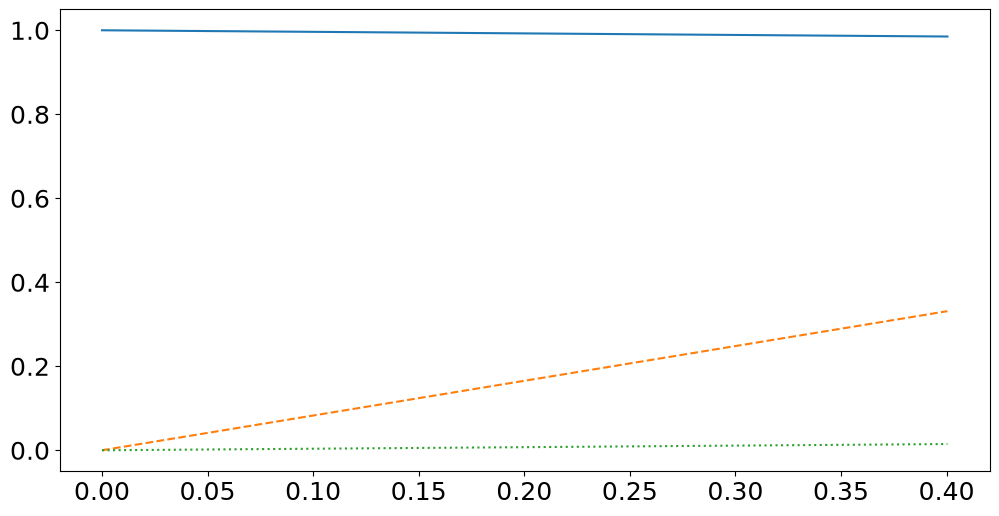

In [13]:
# --- Attempt to solve with the default explicit solver ('RK45') ---
# We will use a relatively loose tolerance to make sure it runs without taking forever.
# Students can try tighter tolerances to see a huge increase in nfev.
print("--- Using the default explicit solver ('RK45') ---")
solution_rk45 = integrate.solve_ivp(robertson_ode, t_span, y0, method='RK45', t_eval=t_eval)
print(f"Number of function evaluations: {solution_rk45.nfev}")
print(f"Solver status: {solution_rk45.status}")
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(solution_rk45.t, solution_rk45.y[0], label='[X]', linestyle='-')
plt.plot(solution_rk45.t, solution_rk45.y[1] * 1e4, label='[Y] x 1e4 (Scaled)', linestyle='--') # Scale Y for visibility
plt.plot(solution_rk45.t, solution_rk45.y[2], label='[Z]', linestyle=':')




As expected, the solver do not produce any results for the original parameters, you can play around the stiffness of the system such as changing the rate constant from $3 \times 10^7$ to $1 \times 10^7$. By doing this, you can observe non-smooth behaviour in the solution. This illustrates the instability of the solver when applied to stiff ODEs. 

--- Using the default explicit solver ('RK45') ---
Number of function evaluations: 3152
Solver status: -1


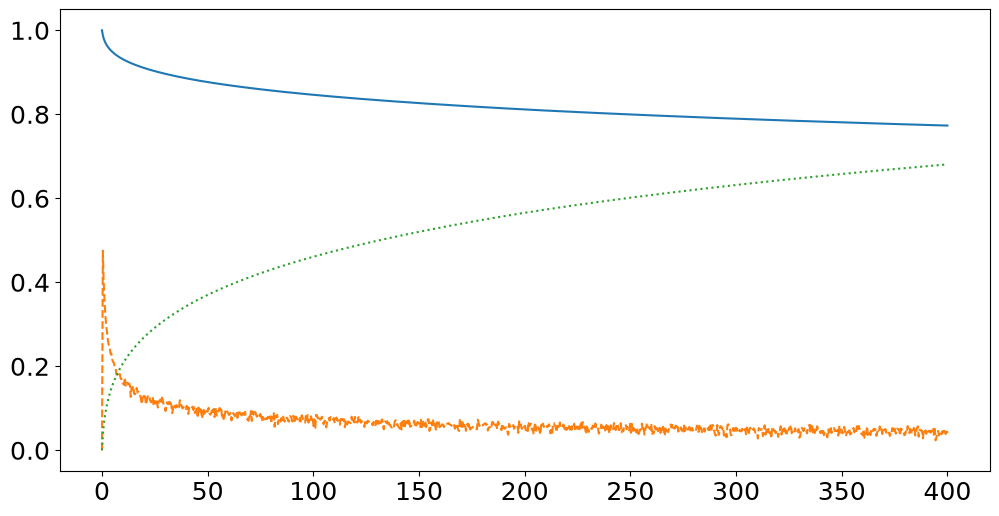

In [14]:
# Define the stiff ODE system (Robertson's problem)
def robertson_relaxed_ode(t, y):
    """
    Defines the system of stiff ODEs for Robertson's chemical reaction.
    y[0] = [X], y[1] = [Y], y[2] = [Z]
    """
    X, Y, Z = y
    dXdt = -0.04 * X + 1e4 * Y * Z
    dYdt = 0.04 * X - 1e4 * Y * Z - 1e7 * Y**2
    dZdt = 3e7 * Y**2
    return [dXdt, dYdt, dZdt]

print("--- Using the default explicit solver ('RK45') ---")
solution_rk45_relaxed = integrate.solve_ivp(robertson_relaxed_ode, t_span, y0, method='RK45', t_eval=t_eval)
print(f"Number of function evaluations: {solution_rk45.nfev}")
print(f"Solver status: {solution_rk45.status}")
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(solution_rk45_relaxed.t, solution_rk45_relaxed.y[0], label='[X]', linestyle='-')
plt.plot(solution_rk45_relaxed.t, solution_rk45_relaxed.y[1] * 1e4, label='[Y] x 1e4 (Scaled)', linestyle='--') # Scale Y for visibility
plt.plot(solution_rk45_relaxed.t, solution_rk45_relaxed.y[2], label='[Z]', linestyle=':')

### Part 2: Implicit Solver ('BDF') Backward Differentiation Formula


Now, we will solve the same problem with a solver specifically designed for stiff systems, `'BDF'`. We expect to see a smooth, stable solution and a much smaller number of function evaluations, demonstrating the efficiency and reliability of using an implicit method for this type of problem.


--- Using an implicit solver ('BDF') ---
Number of function evaluations: 145
Solver status: 0


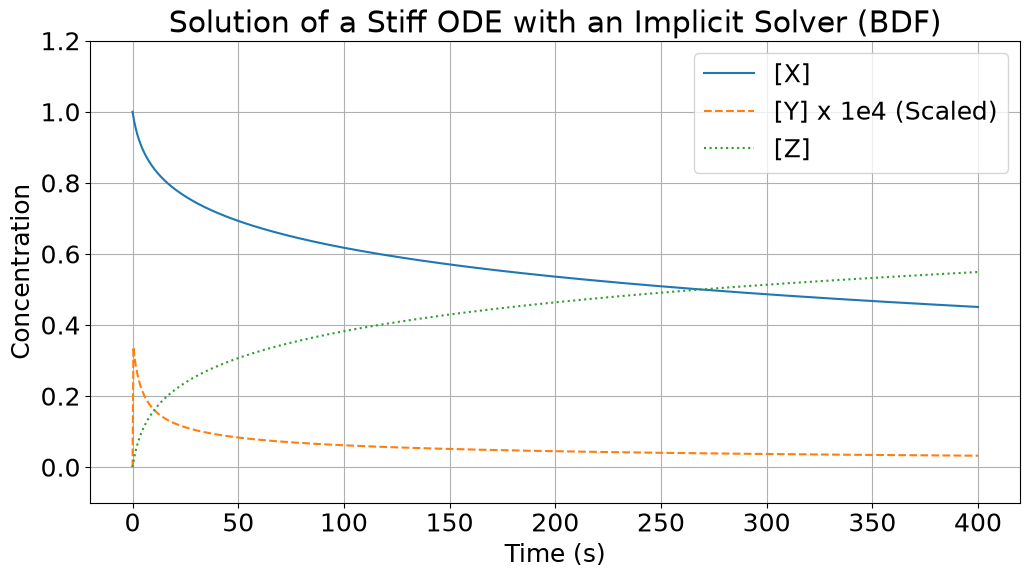

In [ ]:
# --- Solve with an implicit solver ('BDF') ---
# This is a method specifically designed for stiff systems.
print("\n--- Using an implicit solver ('BDF') ---")
solution_bdf = integrate.solve_ivp(robertson_ode, t_span, y0, method='BDF', t_eval=t_eval)

print(f"Number of function evaluations: {solution_bdf.nfev}")
print(f"Solver status: {solution_bdf.status}")

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(solution_bdf.t, solution_bdf.y[0], label='[X]', linestyle='-')
plt.plot(solution_bdf.t, solution_bdf.y[1] * 1e4, label='[Y] x 1e4 (Scaled)', linestyle='--') # Scale Y for visibility
plt.plot(solution_bdf.t, solution_bdf.y[2], label='[Z]', linestyle=':')

# Adding some context to the plot
plt.title("Solution of a Stiff ODE with an Implicit Solver (BDF)")
plt.xlabel("Time (s)")
plt.ylabel("Concentration")
plt.ylim([-0.1, 1.2])
plt.legend()
plt.grid(True)
plt.show()

## Practice Problems



1. Consider a steady-state plug flow reactor, with flow rate $F= 1 m^3/s$ , length $L=5 m$ and cross-sectional
area $A=1 m^2$. Consider a single step first-order, irreversible reaction :

 $$A→B$$

Consider the initial concentration of $A$ to be $1 M$  at the inlet. Perform a component balance over a differential element $dx$ along the reactor. Assume $k=1 s^{-1}$ to be
the rate constant for the reaction. Now, could you frame a first-order differential equation from
this balance? Solve it and plot the concentration profile of A and B along the $x$ direction. Your
answer can only include the code used for this question.

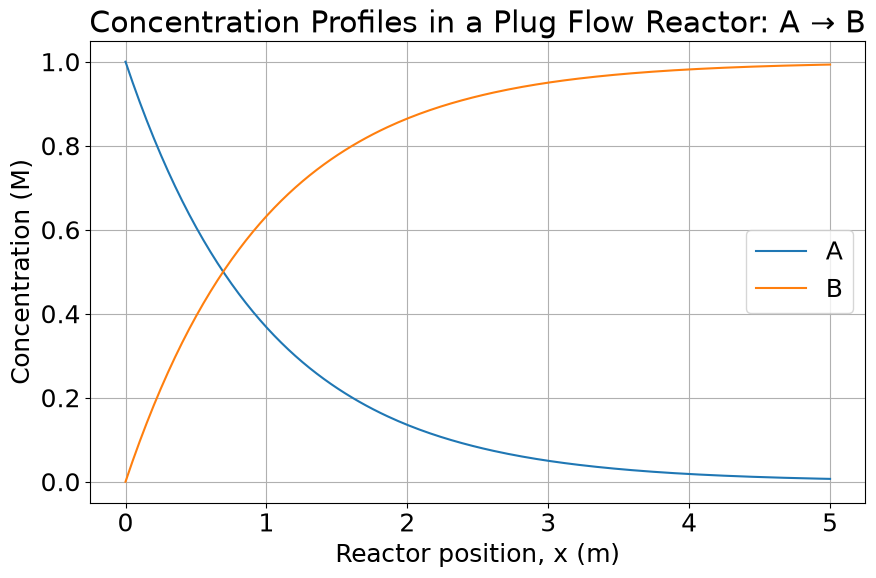

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


CA0 = 1.0
CB0 =0.0 
K =1.0 
F =1.0 
L=5.0
A = 1.0   #A_cross

# 1. declaration of fucntion 
# Concentration is a function of position dx (Volume- A*dx)  
def PFR_MoleFunction(x,C):
    CA , CB =C

    dCAperdx = -(A*K*CA) / F #python cant use fraction bar 
    dCBperdx = (A*K*CA) / F #python cant use fraction bar 

    return [dCAperdx,dCBperdx]
# 2. solve for integration 
x_span = (0, L)
x_eval = np.linspace(0, L, 200)
C_initial = [CA_0,CB_0]

solution = solve_ivp(PFR_MoleFunction, x_span,C_initial,t_eval=x_eval)
x= solution.t
CA=solution.y[0]
CB=solution.y[1]

# Comparison 

CA_analytical = CA0 * np.exp((-A_cross *K)/F)*x

CB_analytical = CA0 +CB0 - CA_analytical

plt.figure(figsize=(10, 6))

plt.plot(x, CA, label='A')
plt.plot(x, CB, label='B')

plt.xlabel('Reactor position, x (m)')
plt.ylabel('Concentration (M)')
plt.title('Concentration Profiles in a Plug Flow Reactor: A → B')

plt.legend()
plt.grid(True)

plt.show()


2. In a well-mixed, isothermal batch reactor, two irreversible reactions occur in unison:
$$A→B$$
$$B→C$$
The volume of this reactor is constant and equal to $3 m^3$. The initial concentration of A is $2M$. Consider a differential time interval $d t$. Frame differential equations for the concentrations of A,
B, and C by considering a balance over time $d t$. The rate constant for the formation of B is $k_1=1.5 s^{-1}$,
and for the degeneration of B to C is $k_2=2 s^{-1}$. Solve these differential equations and plot the
concentrations of all components against time.  Repeat this process, except this time make the value of $k_2=150 s^{-1}$. Write your observations as a comment at the end of your code.

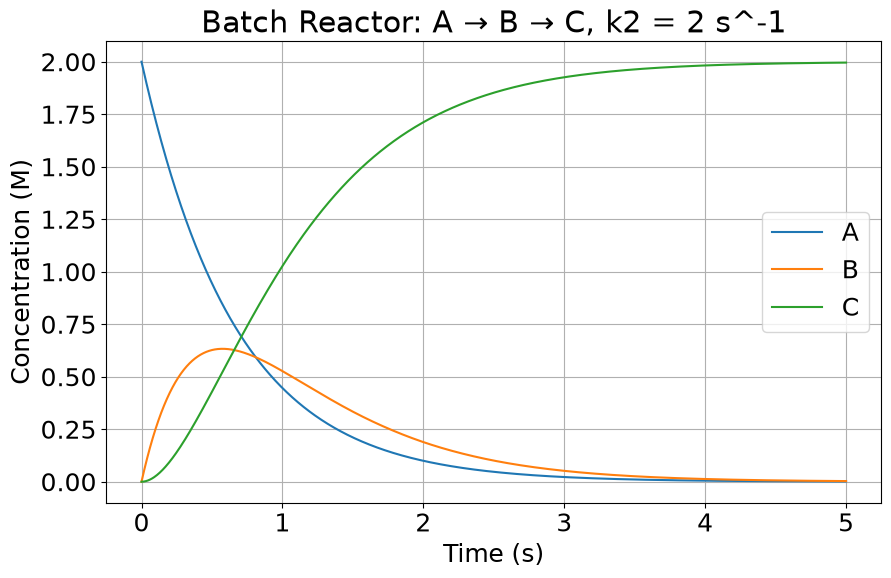

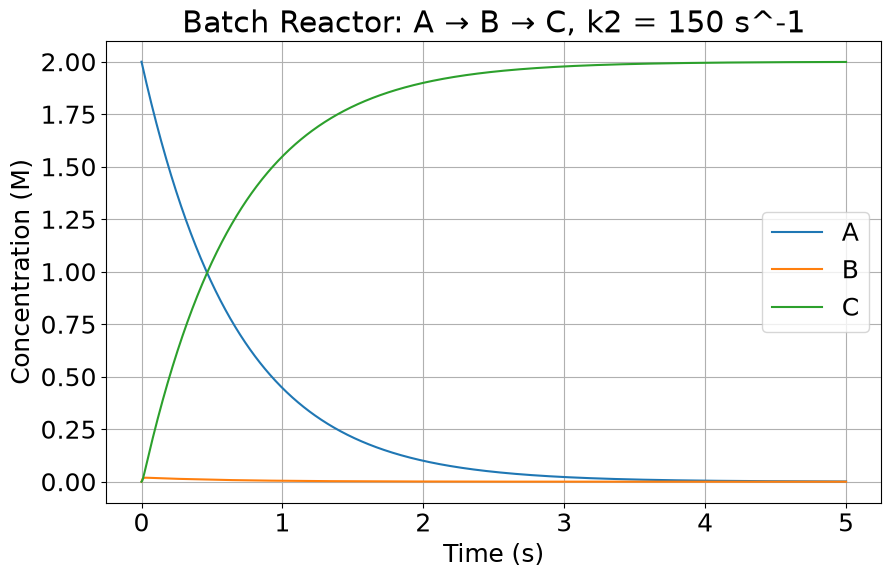

Case 1 final total concentration: 2.0
Case 2 final total concentration: 2.0000000000000004


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


CA0 = 2.0
CB0 =0.0 
CC0 =0.0 

K1 =1.5
K2= 2.0 
V = 3.0

C_initial = [CA0, CB0, CC0]


# 1. declaration of fucntion 

def ModelFunction(t, C, K2):
    CA , CB  , CC = C
    r1 = K1*CA
    r2 = K2*CB
    dCAperdt = -r1
    dCBperdt = r1 - r2
    dCCperdt = r2

    return [dCAperdt,dCBperdt,dCCperdt]
# 2. solve for integration 

t_initial = 0
t_final = 5

t_span = (t_initial, t_final)

t_eval = np.linspace(t_initial, t_final, 1000)

solution_1 = solve_ivp(ModelFunction,   t_span ,C_initial,args=(2.0,), t_eval=t_eval)
t1 = solution_1.t

CA1 = solution_1.y[0]
CB1 = solution_1.y[1]
CC1 = solution_1.y[2]

plt.figure(figsize=(10, 6))

plt.plot(t1, CA1, label='A')
plt.plot(t1, CB1, label='B')
plt.plot(t1, CC1, label='C')

plt.xlabel('Time (s)')
plt.ylabel('Concentration (M)')
plt.title('Batch Reactor: A → B → C, k2 = 2 s^-1')

plt.legend()
plt.grid(True)

plt.show()


# Comparison 

t_initial = 0
t_final = 5

t_span = (t_initial, t_final)

t_eval = np.linspace(t_initial, t_final, 1000)

solution_2 = solve_ivp(ModelFunction,   t_span ,C_initial,args=(150,), t_eval=t_eval)
t2 = solution_2.t

CA2 = solution_2.y[0]
CB2 = solution_2.y[1]
CC2 = solution_2.y[2]

plt.figure(figsize=(10, 6))

plt.plot(t2, CA2, label='A')
plt.plot(t2, CB2, label='B')
plt.plot(t2, CC2, label='C')

plt.xlabel('Time (s)')
plt.ylabel('Concentration (M)')
plt.title('Batch Reactor: A → B → C, k2 = 150 s^-1')

plt.legend()
plt.grid(True)

plt.show()


print("Case 1 final total concentration:",
      CA1[-1] + CB1[-1] + CC1[-1])

print("Case 2 final total concentration:",
      CA2[-1] + CB2[-1] + CC2[-1])

## Observation:
# Observations:
#
# 1. For k2 = 2 s^-1, B initially accumulates because it is
#    produced from A. Later it decreases as it is converted to C.
#
# 2. For k2 = 150 s^-1, B is consumed almost immediately after
#    it is formed, so its concentration remains much smaller.
#
# 3. The disappearance of A is unchanged because:
#
#       dCA/dt = -K1*CA
#
#    and therefore does not depend directly on K2.
#
# 4. CA + CB + CC should remain approximately equal to 2 M.
#
# 5. The k2 = 150 s^-1 case has much more widely separated
#    time scales and is therefore more stiff.
